In [1]:
#Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
from sklearn import svm
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, LSTM 
from tensorflow.keras.models import Sequential
from tensorflow.keras import callbacks

from sklearn.metrics import precision_score, accuracy_score, f1_score, recall_score, confusion_matrix, classification_report

In [3]:
#Data cleaning and analysis

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


C:\Users\SIDDHIKA\AppData\Local\Temp\ipykernel_25460\2817623576.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df["DEATH_EVENT"], palette=cols)


AttributeError: 'Axes' object has no attribute 'bar_labels'

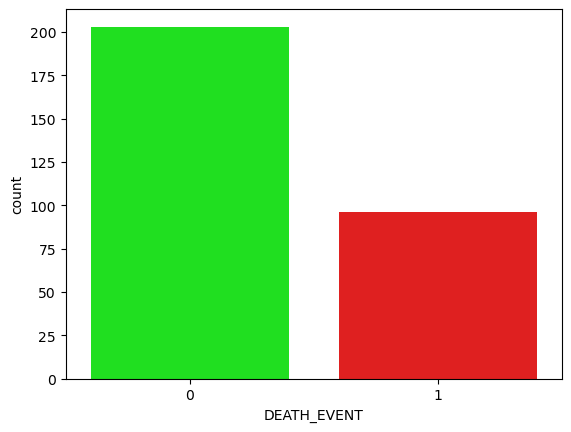

In [5]:
#Visiualization

cols = ["lime", "red"]
ax = sns.countplot(x=df["DEATH_EVENT"], palette=cols)
ax.bar_labels(ax.containers[0])

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


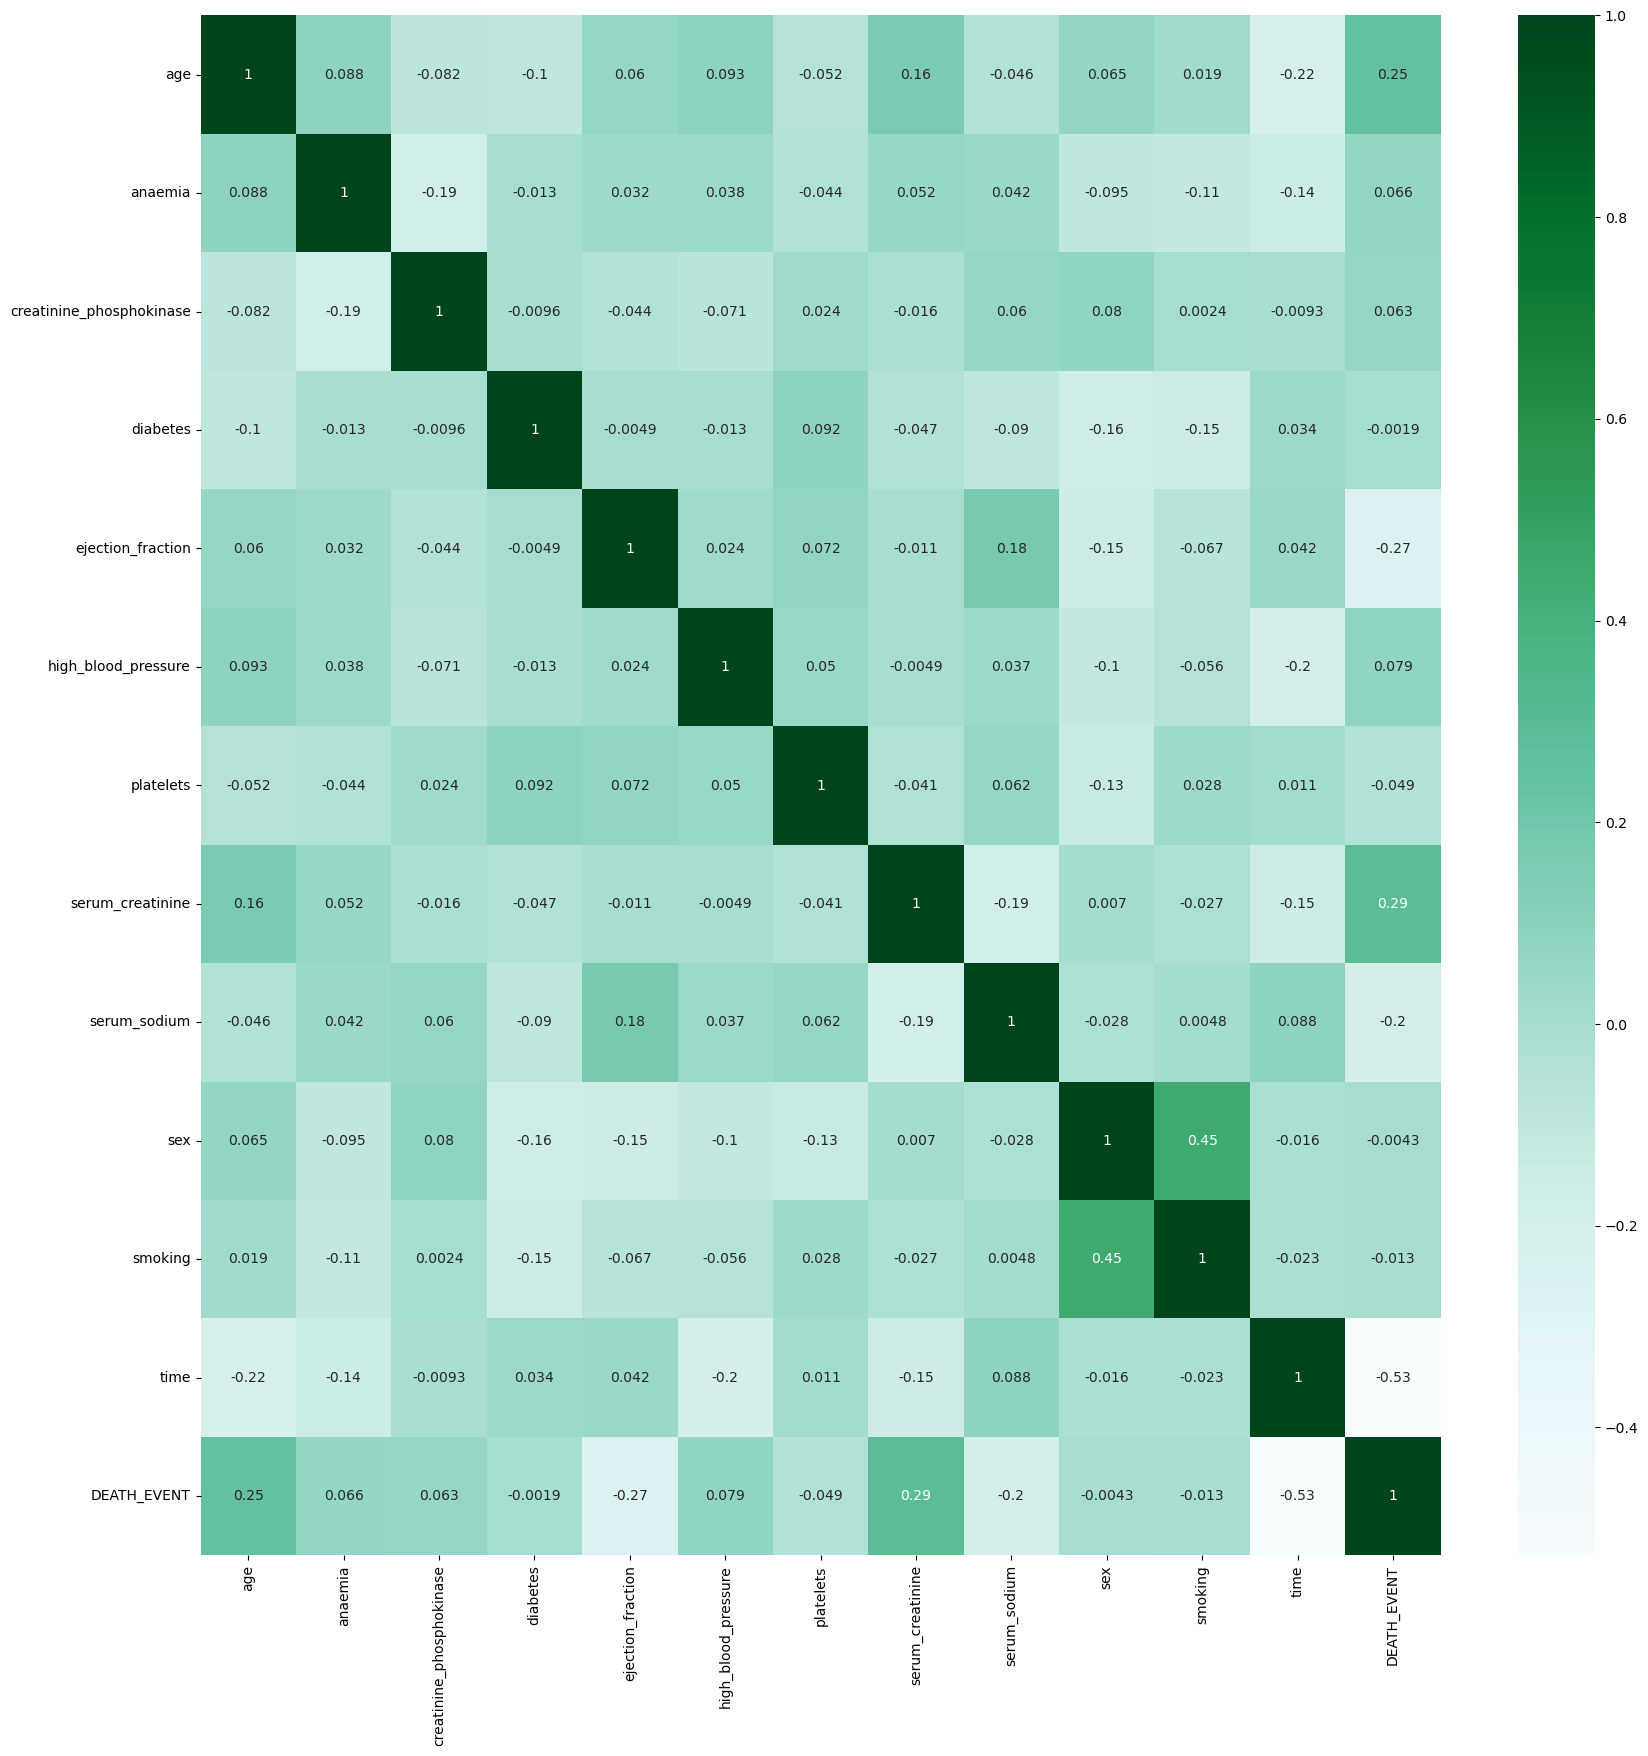

In [7]:
plt.subplots(figsize=(20, 20))
sns.heatmap(df.corr(), cmap="BuGn", annot=True)
plt.show()

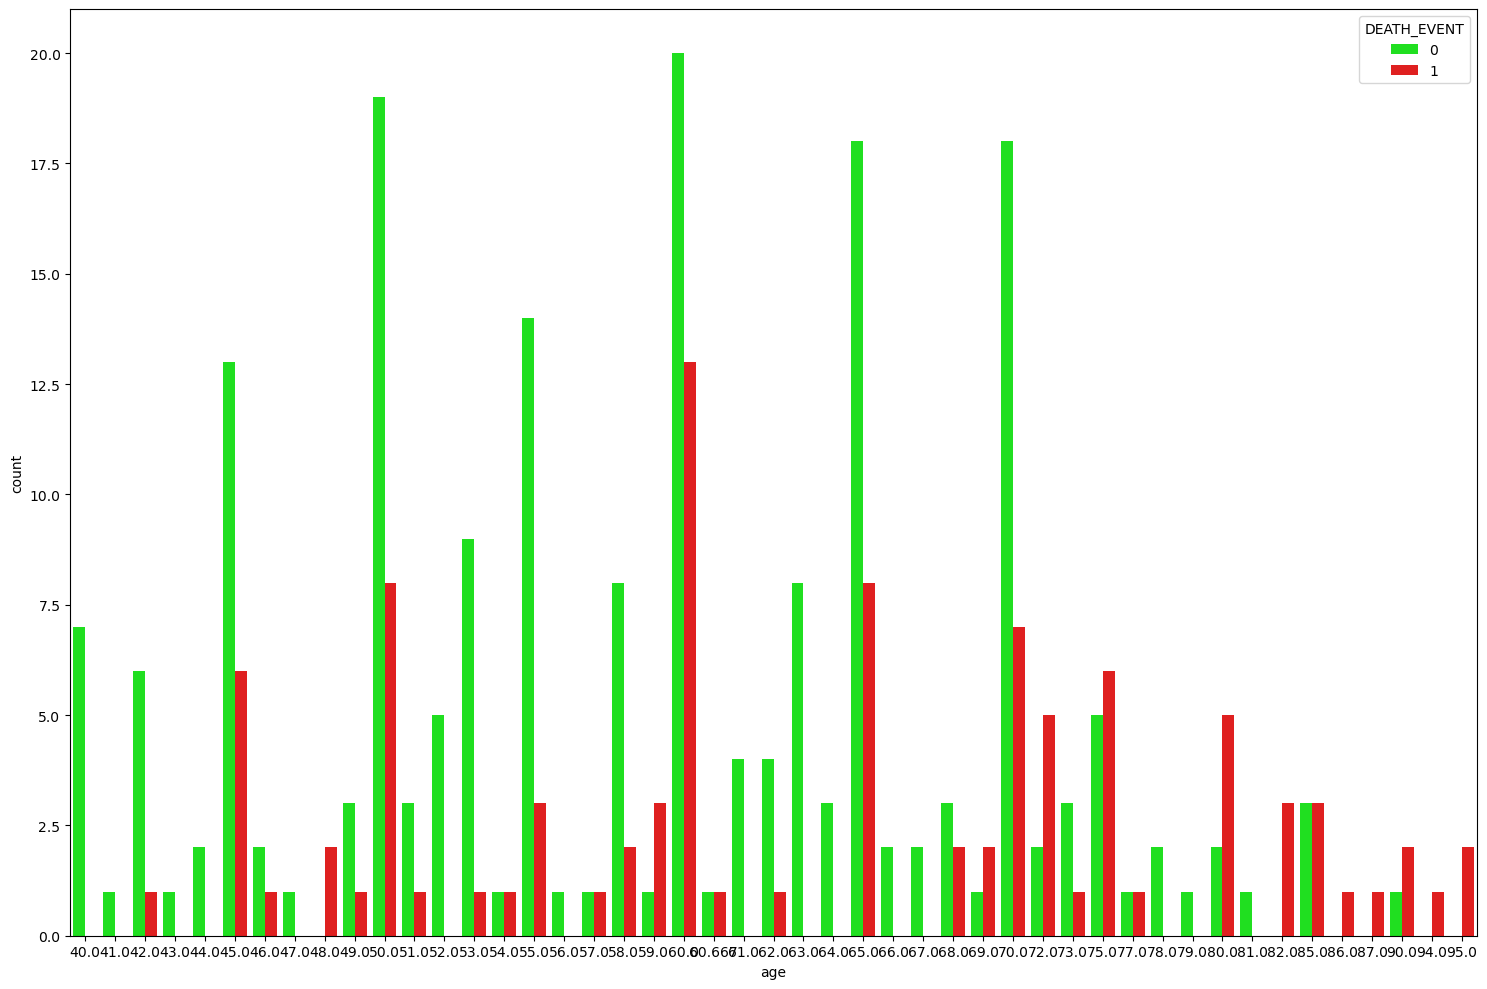

In [8]:
plt.figure(figsize=(15, 10))
days_of_week = sns.countplot(x=df['age'], data=df, hue="DEATH_EVENT", palette= cols)
plt.tight_layout()

C:\Users\SIDDHIKA\AppData\Local\Temp\ipykernel_25460\3422420449.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=df["DEATH_EVENT"], y=df[i], palette = cols)


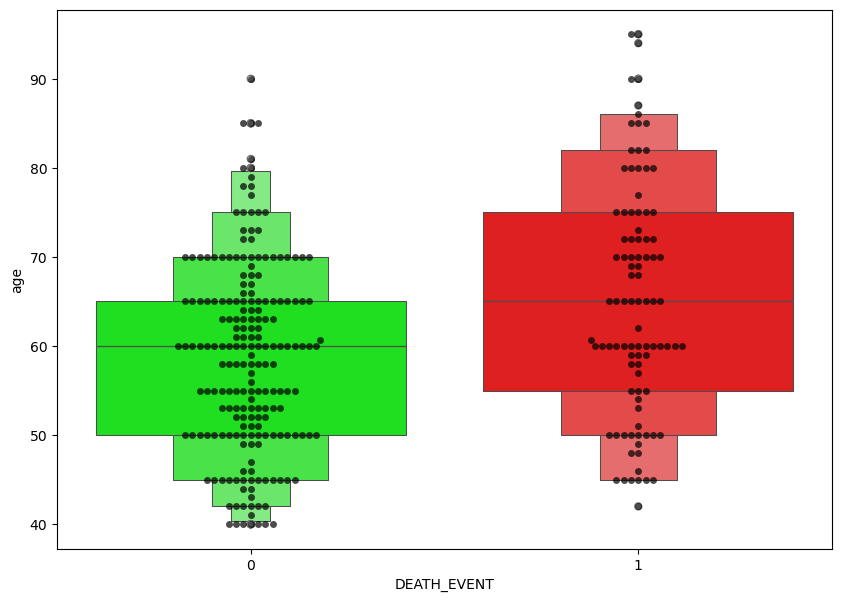

C:\Users\SIDDHIKA\AppData\Local\Temp\ipykernel_25460\3422420449.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=df["DEATH_EVENT"], y=df[i], palette = cols)


<Figure size 640x480 with 0 Axes>

C:\Users\SIDDHIKA\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


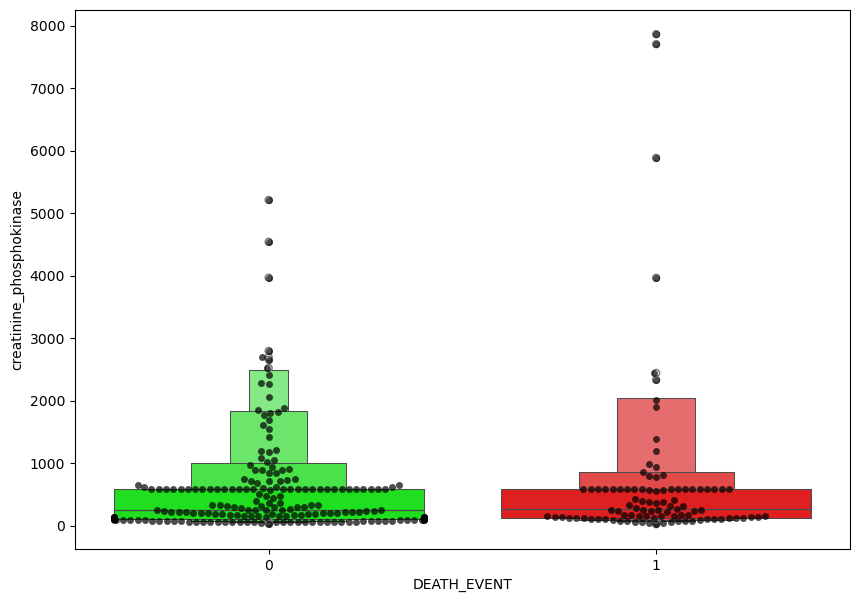

C:\Users\SIDDHIKA\AppData\Local\Temp\ipykernel_25460\3422420449.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=df["DEATH_EVENT"], y=df[i], palette = cols)


<Figure size 640x480 with 0 Axes>

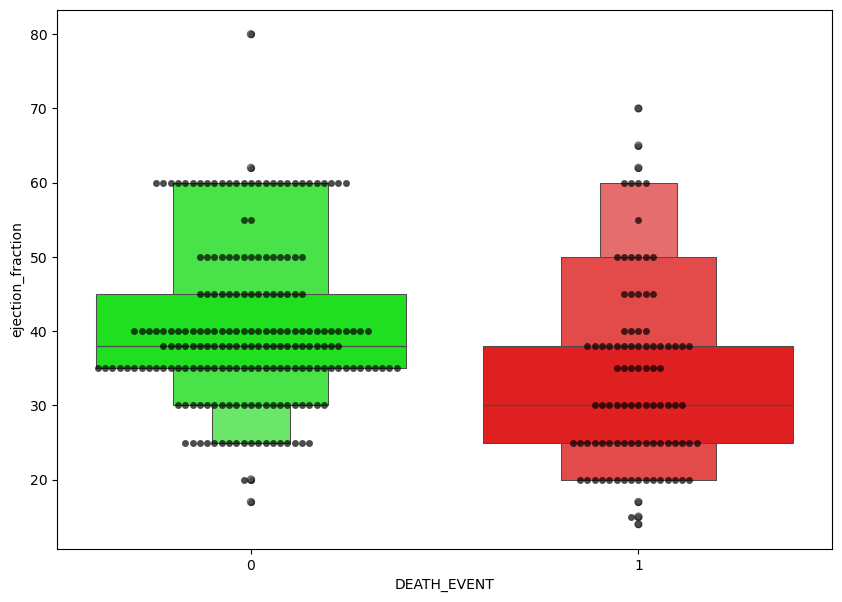

C:\Users\SIDDHIKA\AppData\Local\Temp\ipykernel_25460\3422420449.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=df["DEATH_EVENT"], y=df[i], palette = cols)


<Figure size 640x480 with 0 Axes>

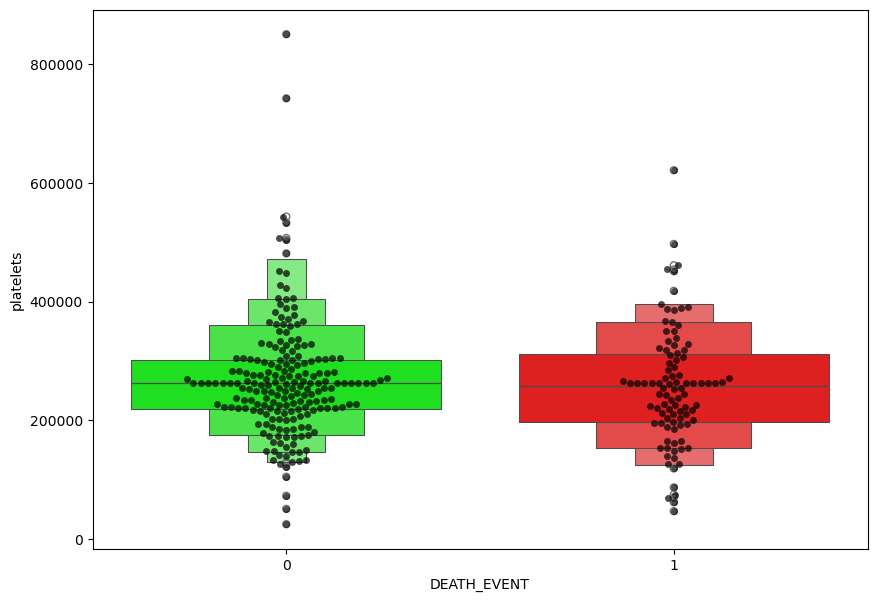

C:\Users\SIDDHIKA\AppData\Local\Temp\ipykernel_25460\3422420449.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=df["DEATH_EVENT"], y=df[i], palette = cols)


<Figure size 640x480 with 0 Axes>

C:\Users\SIDDHIKA\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


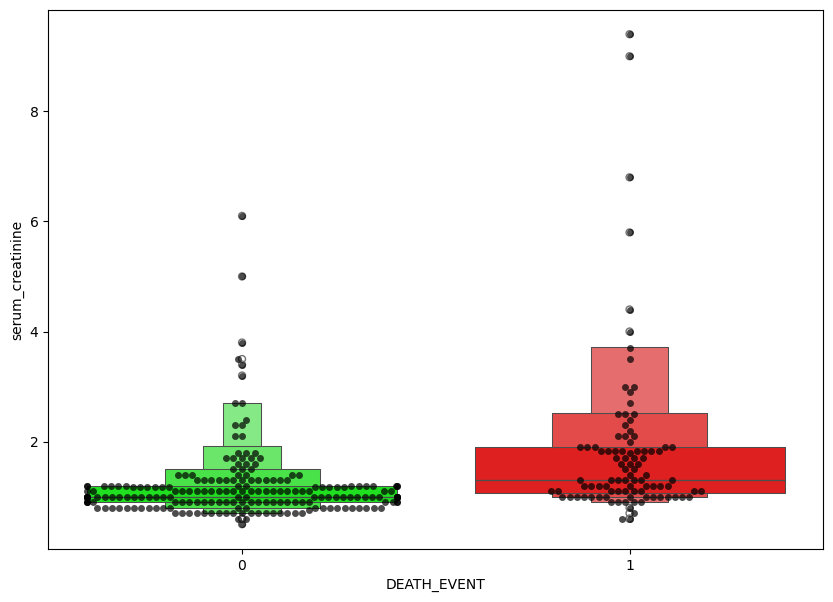

C:\Users\SIDDHIKA\AppData\Local\Temp\ipykernel_25460\3422420449.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=df["DEATH_EVENT"], y=df[i], palette = cols)


<Figure size 640x480 with 0 Axes>

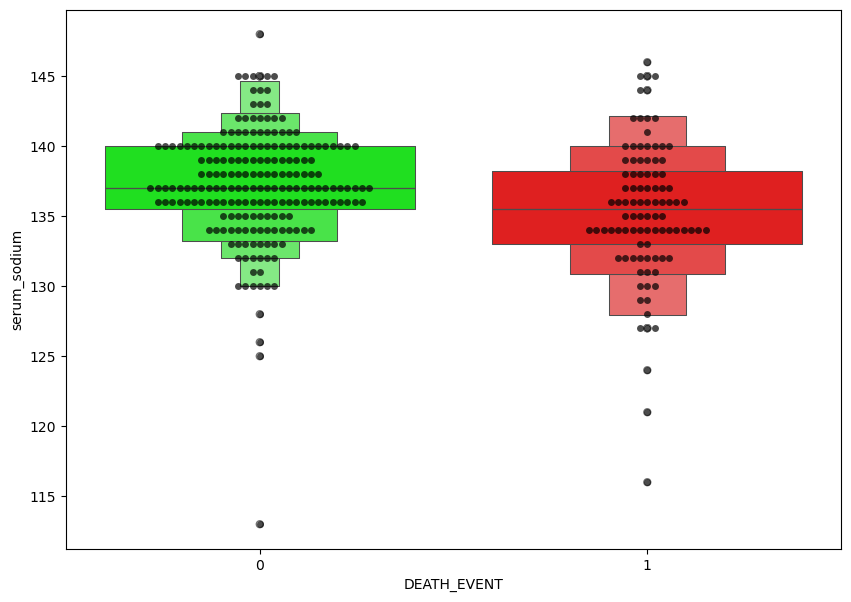

C:\Users\SIDDHIKA\AppData\Local\Temp\ipykernel_25460\3422420449.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=df["DEATH_EVENT"], y=df[i], palette = cols)


<Figure size 640x480 with 0 Axes>

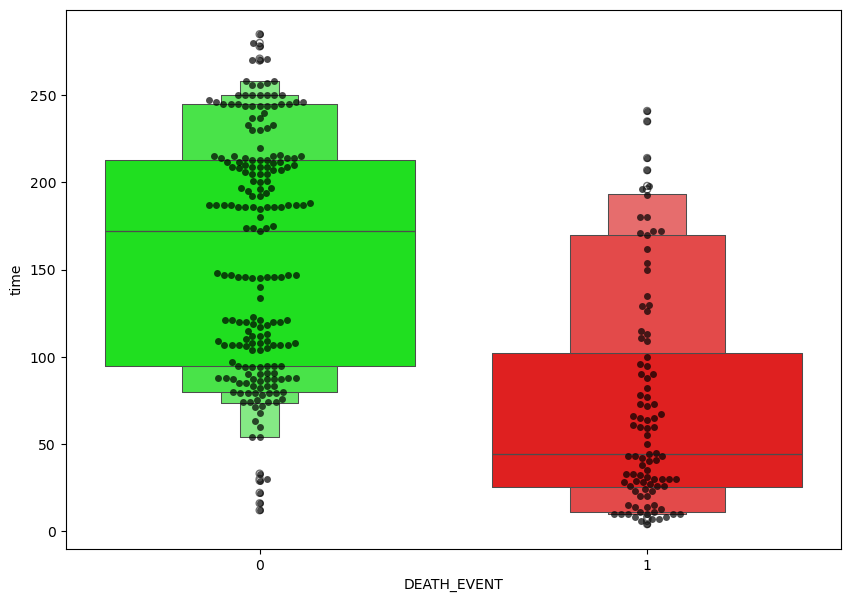

<Figure size 640x480 with 0 Axes>

In [10]:
feature = ["age", "creatinine_phosphokinase", "ejection_fraction", "platelets",
           "serum_creatinine", "serum_sodium", "time"]
for i in feature:
    plt.figure(figsize=(10, 7))
    sns.swarmplot(x=df["DEATH_EVENT"], y=df[i], color = "black", alpha = 0.7)
    sns.boxenplot(x=df["DEATH_EVENT"], y=df[i], palette = cols)
    plt.show()
    plt.tight_layout()

In [11]:
#Data Preprocessing
X = df.drop(["DEATH_EVENT"], axis = 1)
y = df["DEATH_EVENT"]

In [12]:
col_name = list(X.columns)
s_scaler = preprocessing.StandardScaler()
X_scaled = s_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=col_name)

In [13]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,5.703353e-16,1.001676,-1.754448,-0.828124,-0.070223,0.771889,2.877170
anaemia,299.0,1.009969e-16,1.001676,-0.871105,-0.871105,-0.871105,1.147968,1.147968
creatinine_phosphokinase,299.0,0.000000e+00,1.001676,-0.576918,-0.480393,-0.342574,0.000166,7.514640
diabetes,299.0,9.060014e-17,1.001676,-0.847579,-0.847579,-0.847579,1.179830,1.179830
ejection_fraction,299.0,-3.267546e-17,1.001676,-2.038387,-0.684180,-0.007077,0.585389,3.547716
high_blood_pressure,299.0,0.000000e+00,1.001676,-0.735688,-0.735688,-0.735688,1.359272,1.359272
platelets,299.0,7.723291e-17,1.001676,-2.440155,-0.520870,-0.013908,0.411120,6.008180
serum_creatinine,299.0,1.425838e-16,1.001676,-0.865509,-0.478205,-0.284552,0.005926,7.752020
serum_sodium,299.0,-8.673849e-16,1.001676,-5.363206,-0.595996,0.085034,0.766064,2.582144
sex,299.0,-8.911489e-18,1.001676,-1.359272,-1.359272,0.735688,0.735688,0.735688


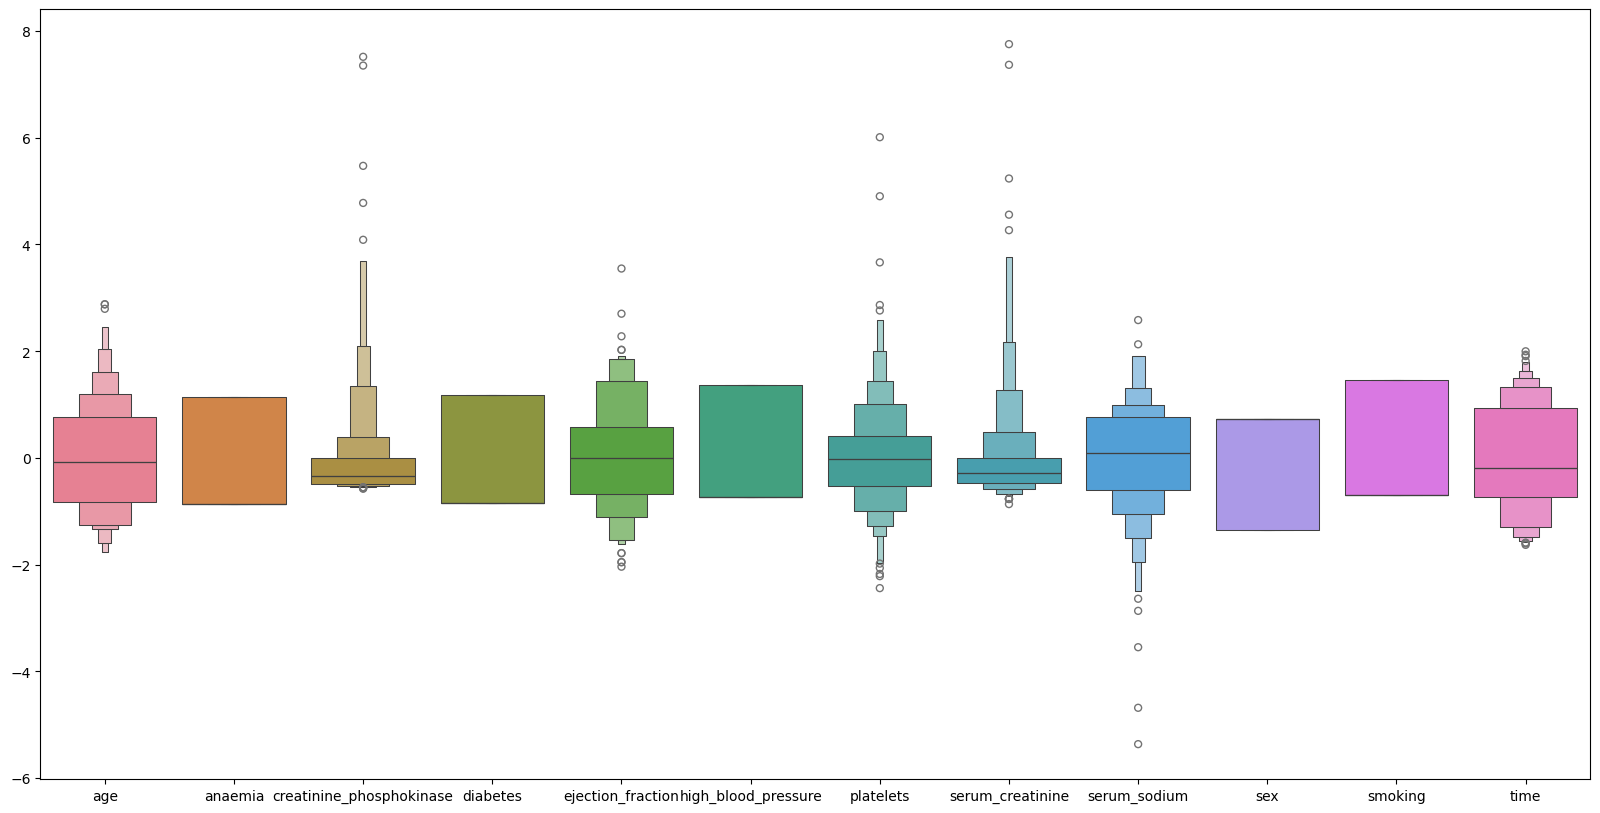

In [14]:
plt.figure(figsize=(20, 10))
sns.boxenplot(data=X_scaled)
plt.show()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2)

In [16]:
#Model training
#SVM
model1 = svm.SVC()

In [17]:
model1.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [18]:
y_pred = model1.predict(X_test)

In [19]:
y_pred

array([1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1])

In [20]:
y_test

36     1
228    0
255    0
35     1
213    1
152    0
84     1
114    0
34     1
231    0
163    1
146    0
15     1
215    0
247    0
286    0
227    0
178    0
248    0
32     1
21     1
212    0
237    0
259    0
31     1
26     1
66     1
70     0
58     1
107    0
221    0
27     1
118    0
274    0
5      1
168    0
291    0
223    0
45     1
224    0
85     0
140    1
13     1
197    0
74     1
261    0
91     0
98     0
211    0
63     1
167    1
181    1
256    0
101    0
220    1
94     0
134    0
117    0
43     0
2      1
Name: DEATH_EVENT, dtype: int64

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.92      0.82        36
           1       0.81      0.54      0.65        24

    accuracy                           0.77        60
   macro avg       0.78      0.73      0.74        60
weighted avg       0.78      0.77      0.76        60



In [58]:
#ANN
early_stopping = callbacks.EarlyStopping(
    min_delta = 0.001, patience=20, restore_best_weights=True
)

model = Sequential()

model.add(Dense(units = 16, kernel_initializer = 'uniform', activation= 'relu', input_dim= 12))
model.add(Dense(units = 8, kernel_initializer = 'uniform', activation= 'relu'))
model.add(Dropout(0.25))
model.add(Dense(units = 8, kernel_initializer = 'uniform', activation= 'relu'))
model.add(Dropout(0.5))
model.add(Dense(units = 1, kernel_initializer = 'uniform', activation= 'sigmoid'))

C:\Users\SIDDHIKA\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics=['accuracy'])

In [50]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 16)                  │             208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 425 (1.66 KB)

 Trainable params: 425 (1.66 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
history = model.fit(X_train, y_train, batch_size=25, epochs=100, callbacks=[early_stopping], validation_split=0.25)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.6592 - loss: 0.6927 - val_accuracy: 0.7333 - val_loss: 0.6913
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6872 - loss: 0.6912 - val_accuracy: 0.7333 - val_loss: 0.6897
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6872 - loss: 0.6900 - val_accuracy: 0.7333 - val_loss: 0.6886
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6872 - loss: 0.6891 - val_accuracy: 0.7333 - val_loss: 0.6870
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6872 - loss: 0.6876 - val_accuracy: 0.7333 - val_loss: 0.6853
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6872 - loss: 0.6862 - val_accuracy: 0.7333 - val_loss: 0.6832
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6872 - loss: 0.6843 - val_accuracy: 0.7333 - val_loss: 0.6809
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6872 - loss: 0.6825 - val_accuracy: 0.7333 - val_loss:

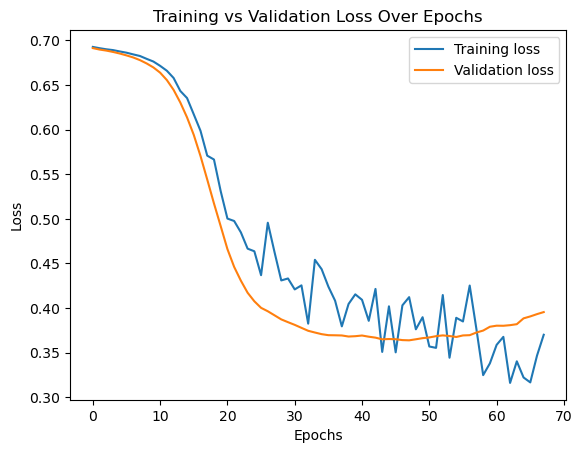

In [61]:
history_df = pd.DataFrame(history.history)

plt.plot(history_df.loc[:, ['loss']], label= "Training loss")
plt.plot(history_df.loc[:, ['val_loss']], label= "Validation loss")
plt.title("Training vs Validation Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

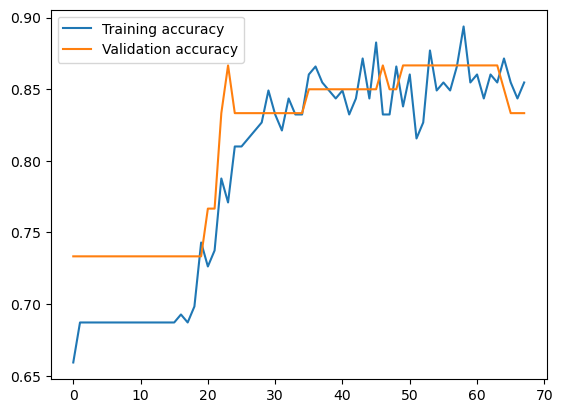

In [62]:
plt.plot(history_df.loc[:, ['accuracy']], label= "Training accuracy")
plt.plot(history_df.loc[:, ['val_accuracy']], label= "Validation accuracy")
plt.legend()
plt.show()

In [63]:
y_pred = model.predict(X_test)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/stepWARNING:tensorflow:6 out of the last 8 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001DE1CEBACA0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


In [64]:
y_pred = (y_pred > 0.5)

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.86      0.81        36
           1       0.74      0.58      0.65        24

    accuracy                           0.75        60
   macro avg       0.75      0.72      0.73        60
weighted avg       0.75      0.75      0.74        60

